In [9]:
import sys
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.utils as vutils

In [10]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

device

device(type='mps')

In [11]:
cwd = Path.cwd()
project_root = cwd.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done")

In [12]:
from Scripts.utils import load_mnist_dataset

In [13]:
data_path = project_root / "data"
train_dataloader, test_dataloader = load_mnist_dataset(
    data_path=data_path,
    batch_size=128
)

In [14]:
next(iter(train_dataloader))

[tensor([[[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         [[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         [[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         ...,
 
 
         [[[-1., -1., -1.,  ..., -

In [15]:
class Generator(nn.Module):
    def __init__(self, noise_size: int):
        super().__init__()

        self.leaky_relu = nn.LeakyReLU()
        self.layer1 = nn.ConvTranspose2d(in_channels=noise_size, out_channels=256, stride=1, padding=0, kernel_size=7)
        self.batch_norm_1 = nn.BatchNorm2d(256)
        self.layer2 = nn.ConvTranspose2d(in_channels=256, out_channels=128, stride=2, padding=1, kernel_size=4)
        self.batch_norm_2 = nn.BatchNorm2d(128)
        self.layer3 = nn.ConvTranspose2d(in_channels=128, out_channels=1, stride=2, padding=1, kernel_size=4)
        self.tanh = nn.Tanh()

    def forward(self, X):
        X = self.layer1(X)          # (128, 256, 7, 7)
        X = self.batch_norm_1(X)    # (128, 256, 7, 7)
        X = self.leaky_relu(X)      # (128, 256, 7, 7)
        X = self.layer2(X)          # (128, 128, 14, 14)
        X = self.batch_norm_2(X)    # (128, 128, 14, 14)
        X = self.leaky_relu(X)      # (128, 128, 14, 14)
        X = self.layer3(X)          # (128, 1, 28, 28)
        X = self.tanh(X)            # (128, 1, 28, 28)

        return X

In [16]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()

        self.leaky_relu = nn.LeakyReLU(negative_slope=0.2)
        self.layer1 = nn.Conv2d(in_channels=1, out_channels=128, stride=2, padding=1, kernel_size=4)
        self.layer2 = nn.Conv2d(in_channels=128, out_channels=256, stride=2, padding=1, kernel_size=4)
        self.layer3 = nn.Conv2d(in_channels=256, out_channels=1, stride=1, padding=0, kernel_size=7)

    def forward(self, X):
        X = self.layer1(X)      # (128, 128, 14, 14)
        X = self.leaky_relu(X)  # (128, 128, 14, 14)
        X = self.layer2(X)      # (128, 256, 7, 7)
        X = self.leaky_relu(X)  # (128, 256, 7, 7)
        X = self.layer3(X)      # (128, 1, 1, 1)

        return X.view(-1, 1)

In [31]:
def calculate_gradient_penalty(device, critic: Critic, batch_size: int, real_samples: np.array, fake_samples: np.array, lbd: int = 10):
    epsilon = torch.rand(size=(batch_size, 1, 1, 1), device=real_samples.device)

    # creating interpolated i.e. the sample between the real dist and learned dist
    x_hat = (epsilon * real_samples + (1 - epsilon) * fake_samples).detach().requires_grad_(True)

    # critic scores
    d_hat = critic(x_hat)

    # calculating the gradients of d_hat wrt x_hat
    grad = torch.autograd.grad(
        outputs=d_hat,
        inputs=x_hat,
        create_graph=True,
        retain_graph=True,
        grad_outputs=torch.ones_like(d_hat)
    )[0]

    # flatten
    grad = grad.view(batch_size, -1)

    # computing l2 norm
    grad_norm = torch.linalg.norm(grad, dim=1)

    return lbd * torch.mean((grad_norm - 1)**2)

In [32]:
def visualize_generated_digits(generator, noise_dim, device, num_images=16):
    """Generates and displays a grid of images from the current generator state."""
    
    # 1. Set generator to evaluation mode (disables dropout, fixes batchnorm stats)
    generator.eval()
    
    # 2. Generate images without tracking gradients (saves memory/compute)
    with torch.no_grad():
        # Create fresh noise
        noise = torch.randn(num_images, noise_dim, 1, 1, device=device)
        # Generate raw fake images
        fake_images = generator(noise)
        
    # 3. Un-normalize the images from [-1, 1] back to [0, 1]
    fake_images = (fake_images + 1) / 2.0
    
    # 4. Arrange the batch of images into a single grid image
    # nrow=4 means a 4x4 grid for 16 images
    grid = vutils.make_grid(fake_images, nrow=4, padding=2, normalize=False)
    
    # 5. Convert to numpy, move to CPU, and rearrange dimensions for matplotlib
    # PyTorch is (C, H, W) -> Matplotlib needs (H, W, C)
    grid_np = grid.cpu().numpy().transpose((1, 2, 0))
    
    # 6. Plot the grid
    plt.figure(figsize=(6, 6))
    plt.axis("off")
    plt.title("WGAN Generated Digits")
    # cmap='gray' is required otherwise matplotlib tries to add artificial colors to 1-channel images
    plt.imshow(grid_np, cmap='gray') 
    plt.show()
    
    # 7. Crucial: Put the generator back into training mode!
    generator.train()

In [36]:
def train(
        device,
        noise_dim: int,
        critic_iterations: int,
        generator: Generator,
        critic: Critic,
        opt_gen: optim.RMSprop,
        opt_crit: optim.RMSprop,
        # schedular_G,
        # schedular_C,
        dataloader,
        epochs: int = 3,
):
    for epoch in range(epochs):
        total_generator_loss = 0.0
        total_critic_loss = 0.0
        for batch, _ in dataloader:
            batch = batch.to(device)
            current_batch_size = batch.shape[0]
            batch_critic_loss = 0.0
            for _ in range(critic_iterations):
                noise = torch.randn(size=[current_batch_size, noise_dim, 1, 1], device=device)
                fake_images = generator(noise).detach()
                critic_real = critic(batch)
                critic_fake = critic(fake_images)
                gp = calculate_gradient_penalty(device=device, critic=critic, batch_size=current_batch_size, real_samples=batch, fake_samples=fake_images)
                critic_loss = torch.mean(critic_fake) - torch.mean(critic_real) + gp
                batch_critic_loss += critic_loss.item()

                # backward
                opt_crit.zero_grad()
                critic_loss.backward()
                opt_crit.step()
            
            total_critic_loss += batch_critic_loss/critic_iterations

            new_noise = torch.randn(size=[current_batch_size, noise_dim, 1, 1], device=device)
            new_fake_images = generator.forward(new_noise)
            critic_score = critic.forward(new_fake_images)
            generator_loss = -torch.mean(critic_score)
            total_generator_loss += generator_loss.item()

            # backward
            opt_gen.zero_grad()
            generator_loss.backward()
            opt_gen.step()
        
        avg_gen_loss = total_generator_loss / len(dataloader)
        avg_crit_loss = total_critic_loss / len(dataloader)
        print(f"Epoch: ({epoch+1}/{epochs}) | Avg Gen Loss: {avg_gen_loss:.4f} | Avg Critic Loss: {avg_crit_loss:.4f}")

        # schedular_G.step()
        # schedular_C.step()

        # visualize
        visualize_generated_digits(generator, noise_dim, device)

    return generator, critic

In [ ]:
# Hyperparameters
LEARNING_RATE = 1e-4
NOISE_DIM = 100
BATCH_SIZE = 128
CRITIC_ITERATIONS = 5

# INITIALIZING THE GENERATOR AND THE DISCRIMINATOR
generator = Generator(noise_size=NOISE_DIM).to(device=device)
critic = Critic().to(device=device)

# Initializing the optimizers
opt_gen  = optim.Adam(params=generator.parameters(), lr=LEARNING_RATE, betas=(0.0, 0.9))
opt_crit = optim.Adam(params=critic.parameters(),    lr=LEARNING_RATE, betas=(0.0, 0.9))

# Initializing the schedulars
# scheduler_G = optim.lr_scheduler.StepLR(opt_gen, step_size=10, gamma=0.5)
# scheduler_C = optim.lr_scheduler.StepLR(opt_crit, step_size=10, gamma=0.5)

In [35]:
trained_generator, trained_critic = train(
    device=device,
    noise_dim=NOISE_DIM,
    batch_size=BATCH_SIZE,
    critic_iterations=CRITIC_ITERATIONS,
    generator=generator,
    critic=critic,
    opt_gen=opt_gen,
    opt_crit=opt_crit,
    dataloader=train_dataloader
)

KeyboardInterrupt: 

In [38]:
trained_model_cpt_path = project_root / "data" / "WGAN_GP_checkpoint.pth"
checkpoint = torch.load(str(trained_model_cpt_path), map_location=device)

In [39]:
trained_generator = Generator(noise_size=checkpoint['noise_dim'])
trained_critic = Critic()

In [40]:
trained_generator.load_state_dict(checkpoint['trained_generator'])
trained_critic.load_state_dict(checkpoint['trained_critic'])

<All keys matched successfully>

In [43]:
trained_generator.to(device)
trained_generator.eval()

Generator(
  (leaky_relu): LeakyReLU(negative_slope=0.01)
  (layer1): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1))
  (batch_norm_1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (batch_norm_2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer3): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (tanh): Tanh()
)

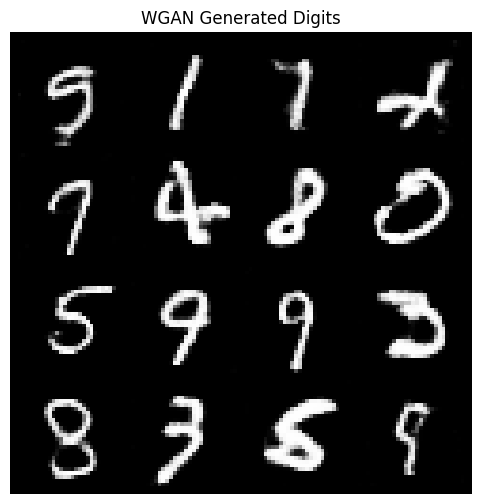

In [47]:
visualize_generated_digits(
    generator=trained_generator,
    noise_dim=checkpoint['noise_dim'],
    device=device
)